In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# Load datasets

df1 = pd.read_csv("medical_records.csv")
df2 = pd.read_csv("patient_details.csv")
print(df1)

    record_id patient_id     diagnosis      bp  sugar_level  visit_cost
0        R101       P013  Hypertension  120/80        140.0        2000
1        R102       P105      Diabetes  120/80          NaN        2500
2        R103       P098  Hypertension    high        140.0        3000
3        R104       P038        Asthma  140/90          NaN        3000
4        R105       P040        Asthma  130/85          NaN        1500
..        ...        ...           ...     ...          ...         ...
115      R216       P081        Asthma    high        110.0        2500
116      R217       P033      Diabetes    high          NaN        1500
117      R218       P063  Hypertension  140/90          NaN        2000
118      R219       P011  Hypertension  130/85        180.0        2500
119      R220       P013  Hypertension    high        180.0        1500

[120 rows x 6 columns]


In [42]:
print(df2)

    patient_id          name   age  gender     city admission_date height_cm
0         P001           NaN  25.0       F   mumbai     15/01/2024       180
1         P002  Rahul Sharma  60.0       F    Delhi     2024/01/16       170
2         P003    Neha Singh  45.0       M   Mumbai     2024/01/16       150
3         P004    Neha Singh  60.0    Male  kolkata     15/01/2024       170
4         P005    Neha Singh  25.0    Male  kolkata     2024-01-15       180
..         ...           ...   ...     ...      ...            ...       ...
125       P006   Anita Verma  25.0       M   Mumbai     2024-01-15       150
126       P007    Neha Singh  25.0       F  kolkata     15/01/2024       150
127       P008     John Paul  60.0       F  Chennai     2024-01-15       160
128       P009           NaN  45.0       M   Mumbai     2024-01-15       150
129       P010  Rahul Sharma  60.0  Female  Chennai     2024/01/16       150

[130 rows x 7 columns]


In [43]:
# Merge on patient_id (inner join)
df = pd.merge(df1, df2, on="patient_id", how="inner")
print(df)

    record_id patient_id     diagnosis      bp  sugar_level  visit_cost  \
0        R101       P013  Hypertension  120/80        140.0        2000   
1        R102       P105      Diabetes  120/80          NaN        2500   
2        R103       P098  Hypertension    high        140.0        3000   
3        R104       P038        Asthma  140/90          NaN        3000   
4        R105       P040        Asthma  130/85          NaN        1500   
..        ...        ...           ...     ...          ...         ...   
126      R216       P081        Asthma    high        110.0        2500   
127      R217       P033      Diabetes    high          NaN        1500   
128      R218       P063  Hypertension  140/90          NaN        2000   
129      R219       P011  Hypertension  130/85        180.0        2500   
130      R220       P013  Hypertension    high        180.0        1500   

             name   age  gender     city admission_date height_cm  
0       John Paul  25.0  Female

In [44]:
# Fill null in name
df["name"] = df["name"].fillna("unknown")

In [45]:
# # Fill null in age
df["age"] = df["age"].fillna(df["age"].mean())


In [46]:
#  Fix negative age
df["age"] = df["age"].abs()

In [47]:
#  Standardize gender
df["gender"] = df["gender"].replace({
    "M": "Male",
    "F": "Female",
    "male": "Male",
    "female": "Female"
})

In [48]:
#  Make city case consistent
df["city"] = df["city"].str.title()

In [49]:
#   Fix date format using regex
df["admission_date"] = df["admission_date"].astype(str)

# Convert formats like dd-mm-yyyy or dd/mm/yyyy → yyyy-mm-dd
df["admission_date"] = df["admission_date"].apply(
    lambda x: re.sub(r"(\d{2})[-/](\d{2})[-/](\d{4})", r"\3-\2-\1", x)
)

df["admission_date"] = pd.to_datetime(df["admission_date"], errors='coerce')


In [50]:
# Remove non-numeric values
df["height_cm"] = df["height_cm"].astype(str).str.replace(r"[^\d.]", "", regex=True)
# Convert to numeric
df["height_cm"] = pd.to_numeric(df["height_cm"], errors='coerce')

# Fill missing with mean
df["height_cm"] = df["height_cm"].fillna(df["height_cm"].mean())


In [51]:
#  Replace "high" in bp
df["bp"] = df["bp"].replace("high", "140/90")

In [52]:
# Impute sugar_level with mean
df["sugar_level"] = df["sugar_level"].fillna(df["sugar_level"].mean())


In [53]:
print(df)

    record_id patient_id     diagnosis      bp  sugar_level  visit_cost  \
0        R101       P013  Hypertension  120/80   140.000000        2000   
1        R102       P105      Diabetes  120/80   141.595745        2500   
2        R103       P098  Hypertension  140/90   140.000000        3000   
3        R104       P038        Asthma  140/90   141.595745        3000   
4        R105       P040        Asthma  130/85   141.595745        1500   
..        ...        ...           ...     ...          ...         ...   
126      R216       P081        Asthma  140/90   110.000000        2500   
127      R217       P033      Diabetes  140/90   141.595745        1500   
128      R218       P063  Hypertension  140/90   141.595745        2000   
129      R219       P011  Hypertension  130/85   180.000000        2500   
130      R220       P013  Hypertension  140/90   180.000000        1500   

             name   age  gender     city admission_date   height_cm  
0       John Paul  25.0  Fema

In [54]:
#  Group by gender
grouped = df.groupby("gender")["visit_cost"].agg(["mean", "min", "max"])
print("\nGrouped Data:\n", grouped)



Grouped Data:
                mean   min   max
gender                         
Female  2231.343284  1500  3000
Male    2359.375000  1500  3000


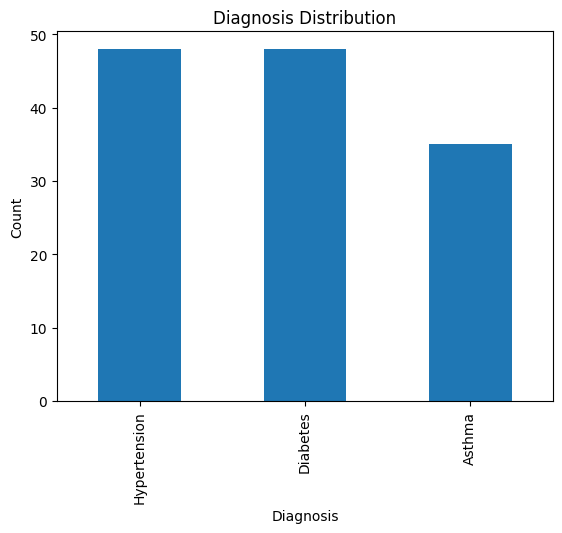

In [55]:
# Histogram on diagnosis
plt.figure()
df["diagnosis"].value_counts().plot(kind="bar")
plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()